# **`Fashion MNIST Neural Network Comparison`**


## **`1. IMPORTING TOOLS WE NEED`**

In [ ]:
# NumPy for working with arrays (images are just arrays of numbers!)
import numpy as np

# Matplotlib and seaborn for making graphs and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras for building neural networks (the cool stuff!)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Scikit-learn tools for evaluating our models
from sklearn.metrics import classification_report, confusion_matrix

# Ignore warning messages so our output looks clean
import warnings
warnings.filterwarnings('ignore')

# Logging helps us see what's happening during training
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')

# For working with file paths (saving models, etc.)
from pathlib import Path

# Joblib for saving Python objects (like our training history)
import joblib

# To time how long training takes
import time

# Set random seeds so we get the same results every time (reproducibility!)
np.random.seed(42)
tf.random.set_seed(42)

# Constants - these are settings we can easily change later
RANDOM_STATE = 42          # For reproducibility
BATCH_SIZE = 32            # How many images to process at once
EPOCHS = 20                # How many times to look at the whole dataset
INPUT_SHAPE = 784          # 28x28 = 784 pixels per image
NUM_CLASSES = 10           # 10 types of clothing
VALIDATION_SPLIT = 0.2     # Use 20% of training data for validation

 ## **`2. LOADING AND PREPARING THE DATA`**

In [ ]:
def load_and_preprocess_data():
    """
    Load Fashion MNIST and get it ready for our neural networks.

    Returns:
        - Flattened training images (for dense networks)
        - Flattened test images
        - Training labels
        - Test labels
        - Class names (what each number means)
        - Original 28x28 images (for displaying)
    """
    print("\nLoading Fashion MNIST dataset...")

    # Fashion MNIST is built into Keras - how convenient!
    fashion_mnist = keras.datasets.fashion_mnist
    (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

    # Class names for the 10 types of clothing
    # The dataset uses numbers 0-9, but these are the actual items
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    # Normalize pixel values from 0-255 to 0-1
    # Neural networks work better with small numbers!
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # Remember our original 28x28 images for displaying later
    x_train_original = x_train.copy()
    x_test_original = x_test.copy()

    # Flatten the 28x28 images into 1D arrays of 784 numbers
    # Dense layers expect 1D input, not 2D images
    x_train_flat = x_train.reshape(x_train.shape[0], -1)
    x_test_flat = x_test.reshape(x_test.shape[0], -1)

    print(f"Training data shape: {x_train_flat.shape} (60,000 images, 784 pixels each)")
    print(f" Test data shape: {x_test_flat.shape} (10,000 images, 784 pixels each)")
    print(f" Number of classes: {len(np.unique(y_train))}")

    return x_train_flat, x_test_flat, y_train, y_test, class_names, x_train_original, x_test_original


def plot_sample_images(images, labels, class_names, num_samples=5):
    """
    Let's look at some actual images from our dataset!

    Args:
        images: The image data
        labels: What each image is
        class_names: Names of the classes
        num_samples: How many images to show
    """
    plt.figure(figsize=(15, 3))

    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)

        # Images are stored as 1D arrays, so we reshape back to 28x28 to display
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    print(" These are sample images from my dataset")


## **`3. BUILDING OUR NEURAL NETWORKS`**

In [ ]:
def create_shallow_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """
    Create a simple neural network with just one hidden layer.

    Architecture:
    - Input layer: 784 neurons (one for each pixel)
    - Hidden layer: 128 neurons with ReLU activation
    - Output layer: 10 neurons with Softmax (gives probabilities for each class)

    This is like a simple baseline model to compare against.
    """
    print("\n Building shallow model...")

    model = keras.Sequential([
        # Hidden layer with 128 neurons
        # ReLU activation helps learn non-linear patterns
        layers.Dense(128, activation='relu', input_shape=(input_shape,),
                    name='hidden_layer'),

        # Output layer with 10 neurons (one for each clothing type)
        # Softmax converts outputs to probabilities that sum to 1
        layers.Dense(num_classes, activation='softmax', name='output_layer')
    ], name='Shallow_Model')

    # Compile the model - this is where we tell it how to learn
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),  # How to update weights
        loss='sparse_categorical_crossentropy',                # How wrong is it?
        metrics=['accuracy']                                    # What to track
    )

    print(" Shallow model ready!")
    return model


def create_deep_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """
    Create a deeper neural network with multiple layers.

    This one has more layers and dropout to prevent overfitting.
    Should perform better than the shallow model (hopefully!).
    """
    print("\n🔨 Building deep model...")

    model = keras.Sequential([
        # Layer 1: 512 neurons
        layers.Dense(512, activation='relu', input_shape=(input_shape,),
                    name='hidden_layer_1'),
        # BatchNorm helps training stabilize
        layers.BatchNormalization(name='batchnorm_1'),
        # Dropout randomly turns off 30% of neurons to prevent overfitting
        layers.Dropout(0.3, name='dropout_1'),

        # Layer 2: 256 neurons
        layers.Dense(256, activation='relu', name='hidden_layer_2'),
        layers.BatchNormalization(name='batchnorm_2'),
        layers.Dropout(0.3, name='dropout_2'),

        # Layer 3: 128 neurons
        layers.Dense(128, activation='relu', name='hidden_layer_3'),
        layers.BatchNormalization(name='batchnorm_3'),
        layers.Dropout(0.3, name='dropout_3'),

        # Layer 4: 64 neurons
        layers.Dense(64, activation='relu', name='hidden_layer_4'),
        layers.Dropout(0.3, name='dropout_4'),

        # Output layer
        layers.Dense(num_classes, activation='softmax', name='output_layer')
    ], name='Deep_Model')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(" Deep model ready!")
    return model

## **`4. TRAINING SETUP - CALLBACKS HELP US TRAIN BETTER`**

In [ ]:
def get_training_callbacks(model_name):
    """
    Set up callbacks to improve training.

    Callbacks are functions that run during training to help:
    - Stop early if model stops improving (saves time!)
    - Reduce learning rate when stuck
    - Save the best version of the model
    """
    return [
        # Stop training if validation loss doesn't improve for 5 epochs
        # This prevents wasting time and overfitting
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        # Reduce learning rate when progress stalls
        # Helps model fine-tune its learning
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,        # Cut learning rate in half
            patience=3,         # Wait 3 epochs before reducing
            min_lr=1e-6,        # Don't go below this
            verbose=1
        ),

        # Save the model whenever validation accuracy improves
        callbacks.ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]


## **`5. TRAINING FUNCTION`**


In [ ]:
def train_model(model, x_train, y_train, model_name, epochs=EPOCHS, batch_size=BATCH_SIZE):
    """
    Train our model and return the training history.

    This is where the magic happens - the model learns from data!
    """
    print(f"\n{'='*50}")
    print(f" TRAINING {model_name.upper()} MODEL")
    print(f"{'='*50}")

    # Get callbacks for this model
    callbacks = get_training_callbacks(model_name)

    # Time how long training takes
    start_time = time.time()

    # Train the model!
    history = model.fit(
        x_train, y_train,
        validation_split=VALIDATION_SPLIT,  # Use part of training data for validation
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")

    return model, history.history

## **`6. EVALUATION FUNCTIONS - HOW GOOD ARE MY MODELS?`**

In [ ]:
def plot_training_history(histories, labels):
    """
    Plot how our models learned over time.

    These graphs help us see:
    - Did the model learn? (accuracy going up)
    - Is it overfitting? (training vs validation gap)
    - When did it stop improving?
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    colors = ['blue', 'red']

    for idx, (history, label) in enumerate(zip(histories, labels)):
        color = colors[idx % len(colors)]

        # Training accuracy
        axes[0, 0].plot(history['accuracy'], color=color, linestyle='-',
                       label=f'{label} (Train)')

        # Validation accuracy
        axes[0, 1].plot(history['val_accuracy'], color=color, linestyle='--',
                       label=f'{label} (Val)')

        # Training loss
        axes[1, 0].plot(history['loss'], color=color, linestyle='-',
                       label=f'{label} (Train)')

        # Validation loss
        axes[1, 1].plot(history['val_loss'], color=color, linestyle='--',
                       label=f'{label} (Val)')

    # Make the graphs look nice
    axes[0, 0].set_title('Training Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].set_title('Validation Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].set_title('Training Loss')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].set_title('Validation Loss')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    print("These graphs show how our models learned over time")


def plot_confusion_matrices(y_true, preds_shallow, preds_deep, class_names):
    """
    Confusion matrices show where our models get confused.

    Perfect predictions would have all numbers on the diagonal.
    Off-diagonal numbers are mistakes - we can see which items get confused!
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Shallow model confusion matrix
    cm_shallow = confusion_matrix(y_true, preds_shallow)
    sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Shallow Model Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

    # Deep model confusion matrix
    cm_deep = confusion_matrix(y_true, preds_deep)
    sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Reds',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Deep Model Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
    print("Confusion matrices - diagonal is good, off-diagonal are mistakes!")


def analyze_overfitting(history, model_name):
    """
    Check if our model is overfitting (memorizing instead of learning).

    Overfitting happens when model does great on training data but poorly on new data.
    Big gap between training and validation accuracy = overfitting!
    """
    train_acc = history['accuracy'][-1]
    val_acc = history['val_accuracy'][-1]
    train_loss = history['loss'][-1]
    val_loss = history['val_loss'][-1]

    acc_gap = train_acc - val_acc
    loss_gap = val_loss - train_loss

    print(f"\n {model_name} Overfitting Analysis:")
    print(f"  Final Training Accuracy: {train_acc:.4f}")
    print(f"  Final Validation Accuracy: {val_acc:.4f}")
    print(f"  Accuracy Gap (Train - Val): {acc_gap:.4f}")

    if acc_gap > 0.05:
        print("   Significant overfitting detected! Model is memorizing training data.")
    elif acc_gap > 0.02:
        print("  Mild overfitting detected. Could use more regularization.")
    else:
        print("   No significant overfitting detected. Model is generalizing well!")

    return {
        'train_acc': train_acc,
        'val_acc': val_acc,
        'acc_gap': acc_gap,
        'overfitting': acc_gap > 0.05
    }


def compare_complexity(models, model_names):
    """
    Compare how complex our models are (number of parameters).

    More parameters = more complex model = can learn more patterns
    But also = slower training and more likely to overfit
    """
    print("\n" + "="*50)
    print("MODEL COMPLEXITY COMPARISON")
    print("="*50)

    for model, name in zip(models, model_names):
        total_params = model.count_params()
        trainable_params = sum([np.prod(v.shape) for v in model.trainable_weights])

        print(f"\n{name}:")
        print(f"  Total parameters: {total_params:,} (that's {total_params:,} numbers the model learns!)")
        print(f"  Trainable parameters: {trainable_params:,}")
        print(f"  Layers: {len(model.layers)}")


def print_final_summary(shallow_acc, shallow_loss, deep_acc, deep_loss,
                        shallow_params, deep_params):
    """
    Print a nice summary comparing both models.
    """
    print("\n" + "="*50)
    print("FINAL RESULTS SUMMARY")
    print("="*50)

    print(f"\n{'Metric':<25} {'Shallow Model':<20} {'Deep Model':<20}")
    print("-"*65)
    print(f"{'Test Accuracy':<25} {shallow_acc:.4f}{'':16} {deep_acc:.4f}")
    print(f"{'Test Loss':<25} {shallow_loss:.4f}{'':16} {deep_loss:.4f}")
    print(f"{'Parameters':<25} {shallow_params:,}{'':16} {deep_params:,}")

    # Who won?
    if deep_acc > shallow_acc:
        print(f"\nDeep model wins! ({deep_acc-shallow_acc:.4f} better accuracy)")
    else:
        print(f"\nShallow model wins! ({shallow_acc-deep_acc:.4f} better accuracy)")



## **`7. LET'S RUN EVERYTHING!`**


FASHION MNIST CLASSIFICATION EXPERIMENT
We'll compare a shallow vs deep neural network on clothing images!

Loading Fashion MNIST dataset...
Training data shape: (60000, 784) (60,000 images, 784 pixels each)
 Test data shape: (10000, 784) (10,000 images, 784 pixels each)
 Number of classes: 10

 Let's see what we're working with:


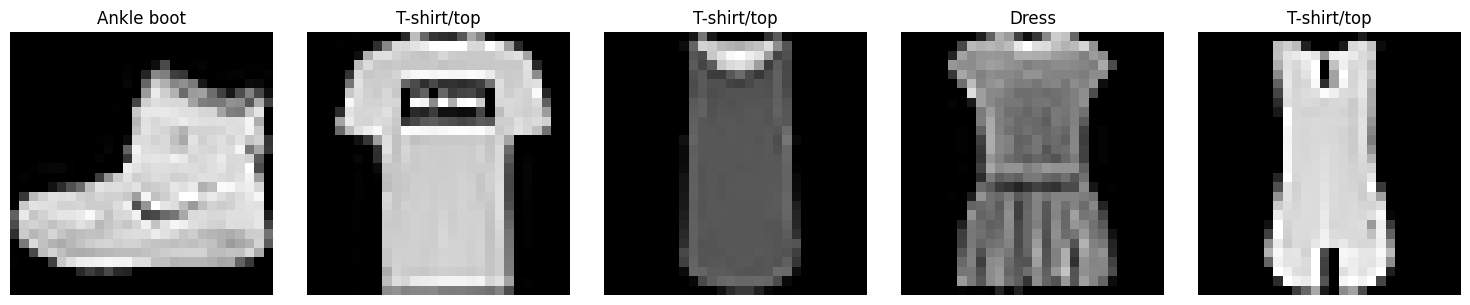

 These are sample images from my dataset

 Building shallow model...
 Shallow model ready!

🔨 Building deep model...
 Deep model ready!

Shallow model architecture:


Model: "Shallow_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_4 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,634 (2.21 MB)

 Trainable params: 576,842 (2.20 MB)

 Non-trainable params: 1,792 (7.00 KB)


Training models... (this might take 5-10 minutes)

 TRAINING SHALLOW MODEL
Epoch 1/20
1492/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7729 - loss: 0.6464
Epoch 1: val_accuracy improved from -inf to 0.84908, saving model to best_shallow.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7732 - loss: 0.6456 - val_accuracy: 0.8491 - val_loss: 0.4293 - learning_rate: 0.0010
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8590 - loss: 0.3940
Epoch 2: val_accuracy improved from 0.84908 to 0.85992, saving model to best_shallow.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8590 - loss: 0.3940 - val_accuracy: 0.8599 - val_loss: 0.3855 - learning_rate: 0.0010
Epoch 3/20
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8753 - loss: 0.3484
Epoch 3: val_accuracy improved from 0.85992 to 0.86758, saving model to best_shallow.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8753 - loss: 0.3484 - val_accuracy: 0.8676 - va

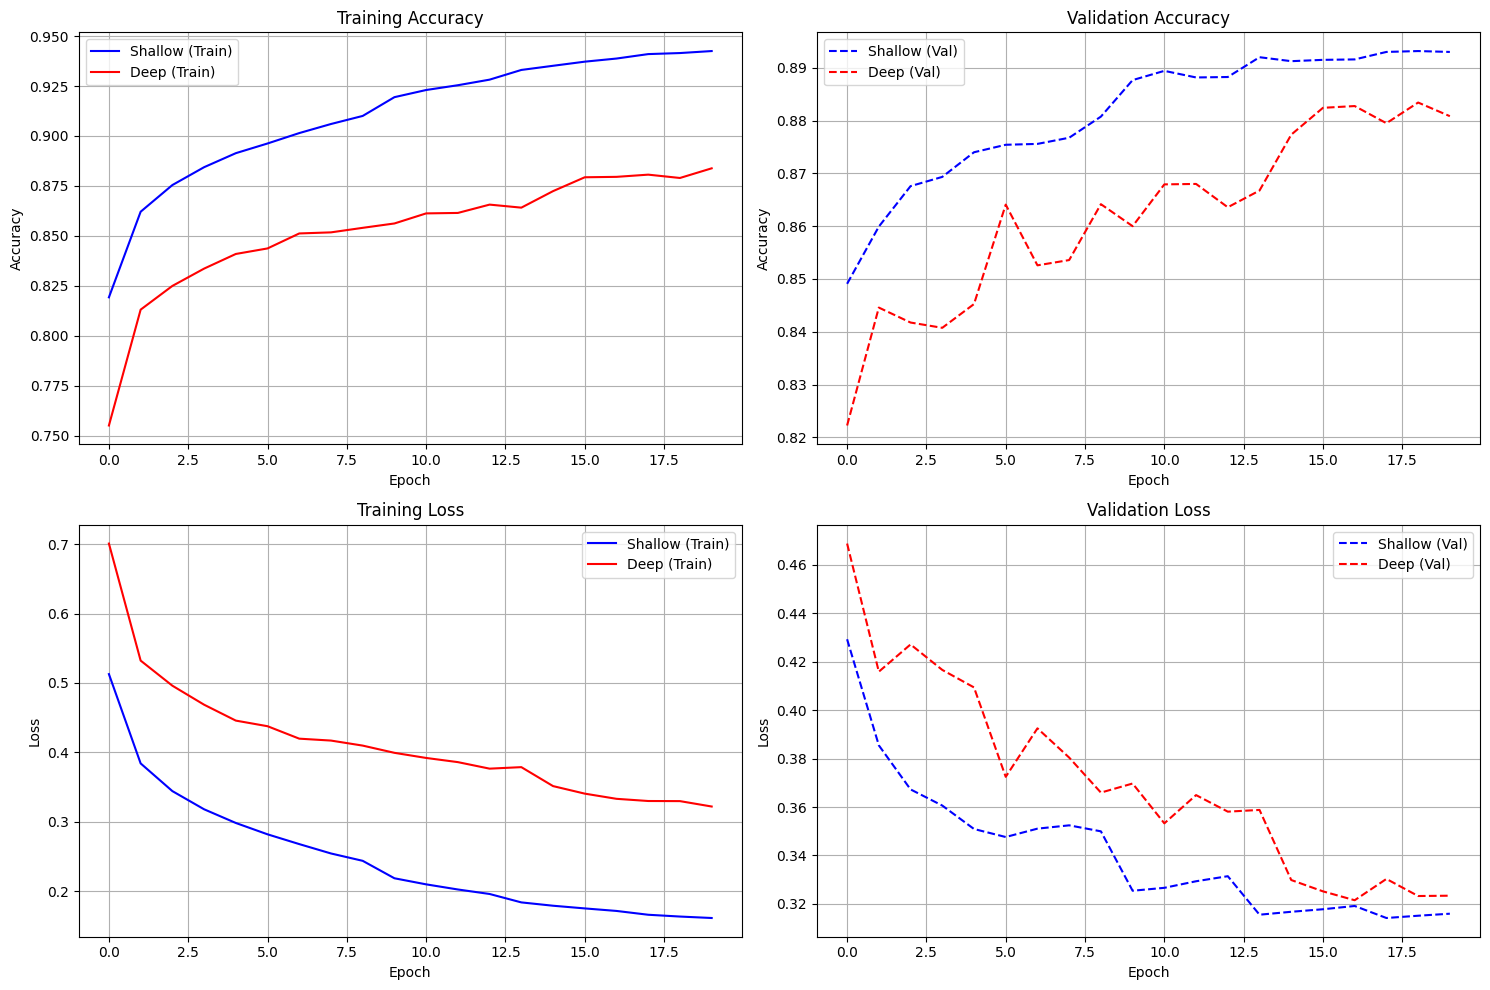

These graphs show how our models learned over time

Generating predictions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report - Shallow Model:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.79      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.80      0.81      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.82      0.81      0.82      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.68      0.76      0.72      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Classification Report - Deep Model:
    

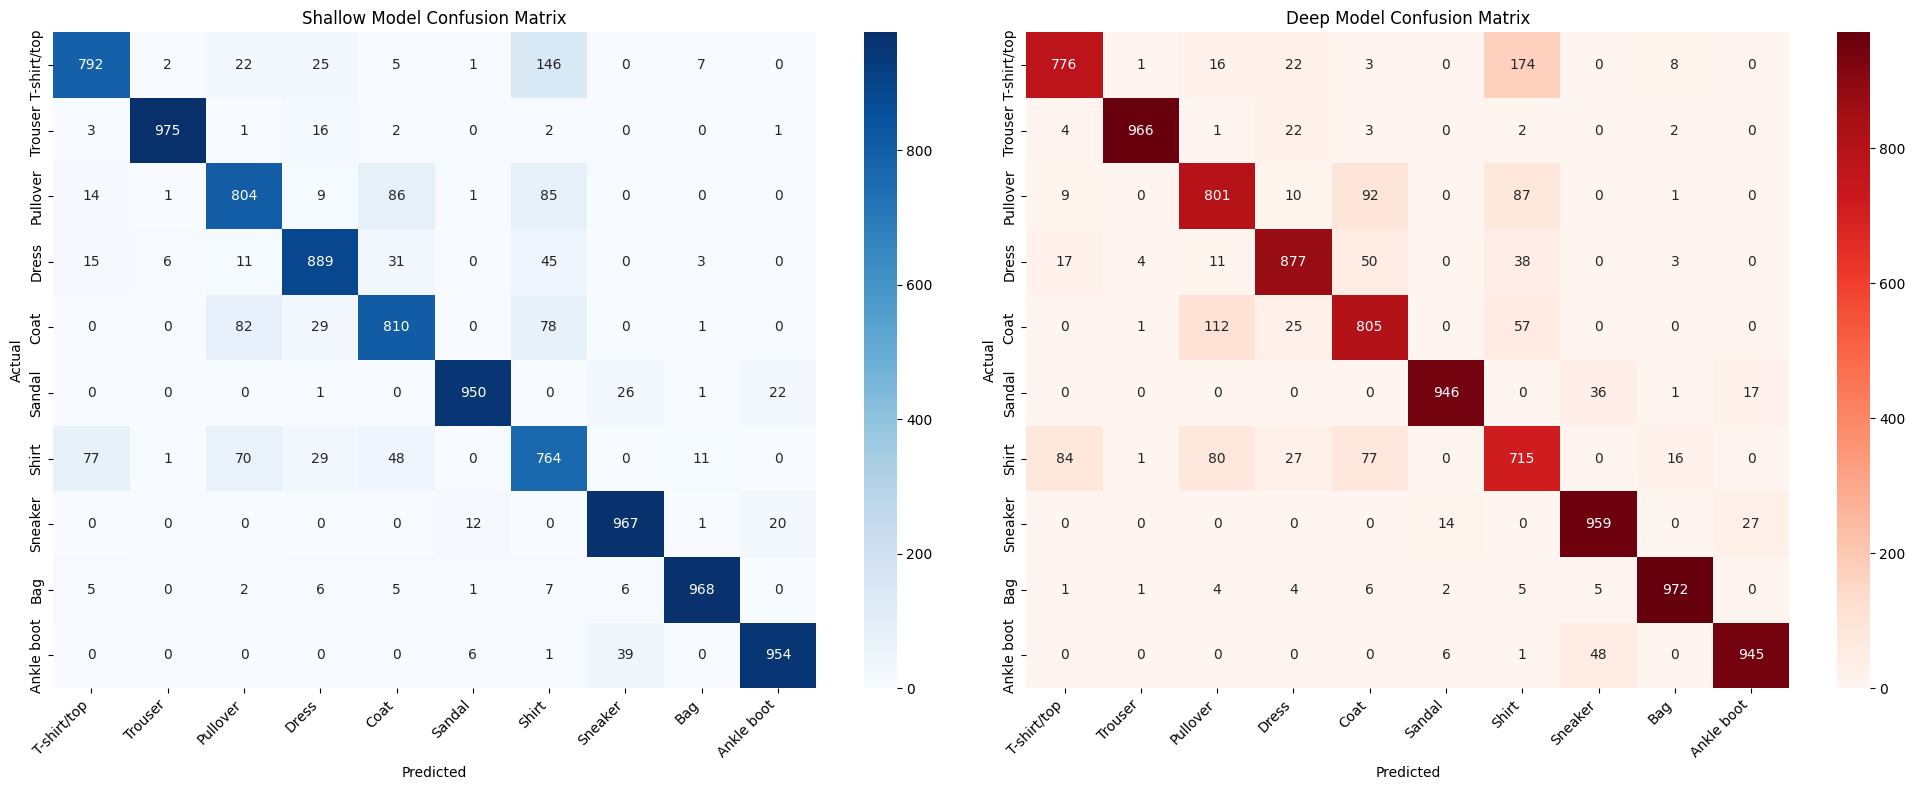

Confusion matrices - diagonal is good, off-diagonal are mistakes!

 Checking for overfitting...

 Shallow Model Overfitting Analysis:
  Final Training Accuracy: 0.9425
  Final Validation Accuracy: 0.8930
  Accuracy Gap (Train - Val): 0.0495
  Mild overfitting detected. Could use more regularization.

 Deep Model Overfitting Analysis:
  Final Training Accuracy: 0.8838
  Final Validation Accuracy: 0.8808
  Accuracy Gap (Train - Val): 0.0030
   No significant overfitting detected. Model is generalizing well!

MODEL COMPLEXITY COMPARISON

Shallow Model:
  Total parameters: 101,770 (that's 101,770 numbers the model learns!)
  Trainable parameters: 101,770
  Layers: 2

Deep Model:
  Total parameters: 578,634 (that's 578,634 numbers the model learns!)
  Trainable parameters: 576,842
  Layers: 12

Saving models...
Models saved in 'models/' folder!

FINAL RESULTS SUMMARY

Metric                    Shallow Model        Deep Model          
--------------------------------------------------------

In [ ]:
def main():
    """Main function that runs our whole experiment."""

    print("\n" + "="*50)
    print("FASHION MNIST CLASSIFICATION EXPERIMENT")
    print("="*50)
    print("We'll compare a shallow vs deep neural network on clothing images!")

    # Step 1: Load and prepare data
    x_train_flat, x_test_flat, y_train, y_test, class_names, x_train_orig, x_test_orig = load_and_preprocess_data()

    # Step 2: Look at some sample images
    print("\n Let's see what we're working with:")
    plot_sample_images(x_train_orig, y_train, class_names)

    # Step 3: Build our models
    shallow_model = create_shallow_model()
    deep_model = create_deep_model()

    # Step 4: Look at model architectures
    print("\nShallow model architecture:")
    shallow_model.summary()

    print("\nDeep model architecture:")
    deep_model.summary()

    # Step 5: Train the models (this takes a few minutes)
    print("\nTraining models... (this might take 5-10 minutes)")
    shallow_model, history_shallow = train_model(
        shallow_model, x_train_flat, y_train, "shallow"
    )
    deep_model, history_deep = train_model(
        deep_model, x_train_flat, y_train, "deep"
    )

    # Step 6: Evaluate on test data
    print("\nEvaluating models on test data...")
    shallow_test_loss, shallow_test_acc = shallow_model.evaluate(
        x_test_flat, y_test, verbose=0
    )
    deep_test_loss, deep_test_acc = deep_model.evaluate(
        x_test_flat, y_test, verbose=0
    )

    print(f"\nResults:")
    print(f"  Shallow Model - Accuracy: {shallow_test_acc:.4f}, Loss: {shallow_test_loss:.4f}")
    print(f"  Deep Model - Accuracy: {deep_test_acc:.4f}, Loss: {deep_test_loss:.4f}")

    # Step 7: Plot training history
    print("\nPlotting training history...")
    plot_training_history([history_shallow, history_deep], ['Shallow', 'Deep'])

    # Step 8: Get predictions
    print("\nGenerating predictions...")
    shallow_preds = shallow_model.predict(x_test_flat)
    deep_preds = deep_model.predict(x_test_flat)

    shallow_pred_classes = np.argmax(shallow_preds, axis=1)
    deep_pred_classes = np.argmax(deep_preds, axis=1)

    # Step 9: Detailed classification reports
    print("\nClassification Report - Shallow Model:")
    print(classification_report(y_test, shallow_pred_classes, target_names=class_names))

    print("\nClassification Report - Deep Model:")
    print(classification_report(y_test, deep_pred_classes, target_names=class_names))

    # Step 10: Confusion matrices
    print("\nPlotting confusion matrices...")
    plot_confusion_matrices(y_test, shallow_pred_classes, deep_pred_classes, class_names)

    # Step 11: Check for overfitting
    print("\n Checking for overfitting...")
    analyze_overfitting(history_shallow, "Shallow Model")
    analyze_overfitting(history_deep, "Deep Model")

    # Step 12: Compare model complexity
    compare_complexity([shallow_model, deep_model], ['Shallow Model', 'Deep Model'])

    # Step 13: Save models for later use
    print("\nSaving models...")
    Path('models').mkdir(exist_ok=True)
    shallow_model.save('models/shallow_fashion_mnist_model.keras')
    deep_model.save('models/deep_fashion_mnist_model.keras')
    print("Models saved in 'models/' folder!")

    # Step 14: Save training histories (so we can plot later without retraining)
    joblib.dump(history_shallow, 'models/shallow_history.pkl')
    joblib.dump(history_deep, 'models/deep_history.pkl')

    # Step 15: Final summary
    print_final_summary(
        shallow_test_acc, shallow_test_loss,
        deep_test_acc, deep_test_loss,
        shallow_model.count_params(), deep_model.count_params()
    )

    print("\n" + "="*50)
    print("EXPERIMENT COMPLETE!")
    print("="*50)
    print("We successfully:")
    print("Built two neural networks from scratch")
    print("Trained them on fashion images")
    print("Compared their performance")
    print("Checked for overfitting")
    print("Saved our models for future use")
    print("\nNext steps to try:")
    print("- Add convolutional layers (CNNs are better for images!)")
    print("- Try different optimizers or learning rates")
    print("- Add more data augmentation")
    print("- Experiment with different architectures")


if __name__ == "__main__":
    main()